<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/01_resin_discovery_framework_gen_o2_temp/NRC_Postdoc_Project/01_Resin_Discovery_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created 'historical_lab_data_gen_o2_temp.csv' with 2000 samples.
Dataset preview (first 5 rows):


,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Resin_Generation,O2_Level,Temperature_C,Ec_mJ_cm2,Dp_um
0,Acrylate_Standard,0.655158,0.248766,2,0.455476,19.957624,15.607178,109.464597
1,Epoxy_Tough,1.645655,0.178229,1,0.118858,26.568106,10.433494,129.332858
2,Epoxy_Tough,0.822575,0.073456,3,0.569173,25.457396,10.989546,161.109116
3,Acrylate_Standard,0.880817,0.223703,3,0.156429,26.508530,13.688705,114.881223
4,Acrylate_Standard,2.080707,0.025344,1,0.060958,26.886339,8.951294,187.265793


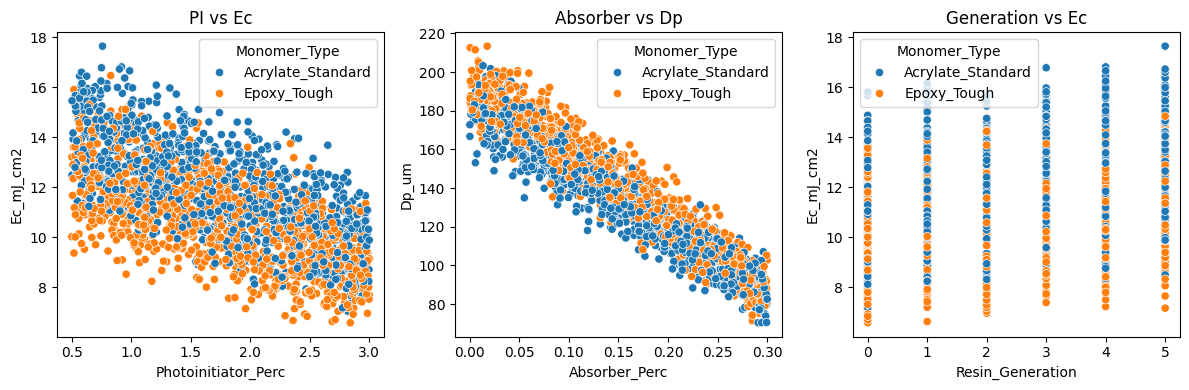

In [1]:
# CELL 1: Imports, configuration, and synthetic data generation

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

import torch
import torch.nn as nn

# --- CONFIGURATION ---
filename = "historical_lab_data_gen_o2_temp.csv"
random.seed(42)
np.random.seed(42)

n_samples = 2000  # synthetic dataset size

# --- 1. GENERATE INPUT FEATURES (FORMULATION + HISTORY + ENVIRONMENT) ---

rng = np.random.default_rng(42)

monomer_types = rng.choice(
    ["Acrylate_Standard", "Epoxy_Tough"],
    size=n_samples
)

photoinitiator_perc = rng.uniform(0.5, 3.0, size=n_samples)   # wt%
absorber_perc       = rng.uniform(0.0, 0.3, size=n_samples)   # wt%

# New features:
resin_generation = rng.integers(0, 6, size=n_samples)         # 0–5 reuse cycles
o2_level         = rng.uniform(0.0, 1.0, size=n_samples)      # 0 = low-O2, 1 = air
temperature_c    = rng.normal(25.0, 4.0, size=n_samples)      # around room temp

df = pd.DataFrame({
    "Monomer_Type":         monomer_types,
    "Photoinitiator_Perc":  photoinitiator_perc,
    "Absorber_Perc":        absorber_perc,
    "Resin_Generation":     resin_generation,
    "O2_Level":             o2_level,
    "Temperature_C":        temperature_c,
})

# --- 2. PHYSICS-INSPIRED MODEL FOR Ec AND Dp ---

def calc_base_ec(row):
    """
    Base cure dose Ec (mJ/cm²) as a function of monomer, PI, and absorber.
    """
    base = 9.0  # baseline sensitivity

    # Epoxy slightly more reactive (lower Ec)
    if row["Monomer_Type"] == "Epoxy_Tough":
        base *= 0.9

    # More photoinitiator -> lower Ec (simple monotonic toy model)
    base *= 1.0 - 0.15 * (row["Photoinitiator_Perc"] - 1.5)

    # More absorber slightly increases required dose (less light makes it through)
    base *= 1.0 + 1.5 * row["Absorber_Perc"]

    return base


def calc_base_dp(row):
    """
    Base penetration depth Dp (µm) as a function of monomer, PI, and absorber.
    """
    base = 200.0  # baseline Dp

    if row["Monomer_Type"] == "Epoxy_Tough":
        base *= 1.05  # epoxy slightly higher Dp

    # More absorber -> shorter Dp
    base *= 1.0 - 1.8 * row["Absorber_Perc"]

    # PI has a small effect on Dp
    base *= 1.0 - 0.03 * (row["Photoinitiator_Perc"] - 1.5)

    return base


ec_list = []
dp_list = []

for _, row in df.iterrows():
    base_ec = calc_base_ec(row)
    base_dp = calc_base_dp(row)

    gen  = row["Resin_Generation"]
    o2   = row["O2_Level"]       # 0 = low-O2, 1 = air
    temp = row["Temperature_C"]  # °C

    # ---- Ec modifiers ----
    # Aging: Ec increases with reuse (PI depletion, inhibitor buildup)
    aging_factor_ec = 1.0 + 0.03 * gen        # +3% per generation

    # Oxygen: more O2 makes cure harder (inhibition)
    o2_factor_ec    = 1.0 + 0.08 * o2         # up to ~+8% in air

    # Temperature: hotter resin -> slightly lower Ec (faster kinetics)
    temp_factor_ec  = 1.0 - 0.03 * ((temp - 25.0) / 5.0)

    # ---- Dp modifiers ----
    # Aging: Dp decreases with reuse (more scattering/absorbers)
    aging_factor_dp = 1.0 - 0.02 * gen

    # Oxygen: more O2 slightly reduces effective Dp
    o2_factor_dp    = 1.0 - 0.05 * o2

    # Temperature: hotter -> slightly deeper Dp
    temp_factor_dp  = 1.0 + 0.02 * ((temp - 25.0) / 5.0)

    # Clip Dp factor so it doesn't go crazy
    dp_factor = max(0.4, aging_factor_dp * o2_factor_dp * temp_factor_dp)

    ec = base_ec * aging_factor_ec * o2_factor_ec * temp_factor_ec
    dp = base_dp * dp_factor

    # Add some experimental noise
    ec += rng.normal(0.0, 0.4)   # mJ/cm² noise
    dp += rng.normal(0.0, 6.0)   # µm noise

    ec_list.append(ec)
    dp_list.append(dp)

df["Ec_mJ_cm2"] = np.clip(ec_list, 1.0, None)
df["Dp_um"]     = np.clip(dp_list, 10.0, None)

# Save for reproducibility if desired
df.to_csv(filename, index=False)

print(f"Created '{filename}' with {n_samples} samples.")
print("Dataset preview (first 5 rows):")
display(df.head())

# Quick sanity plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x="Photoinitiator_Perc", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("PI vs Ec")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x="Absorber_Perc", y="Dp_um", hue="Monomer_Type")
plt.title("Absorber vs Dp")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x="Resin_Generation", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("Generation vs Ec")

plt.tight_layout()
plt.show()
